# Optimization: Finding the Lowest Point in a Landscape

In this notebook, we explore how to find the 'optimum' (the minimum or maximum) of a function with multiple inputs. Imagine you are a surveyor looking for the lowest point in a valley described by the height function:

$$f(x, y) = (x - 2)^2 - xy + (y - 3)^2$$

We will look at three ways to find where $f(x,y)$ is smallest.

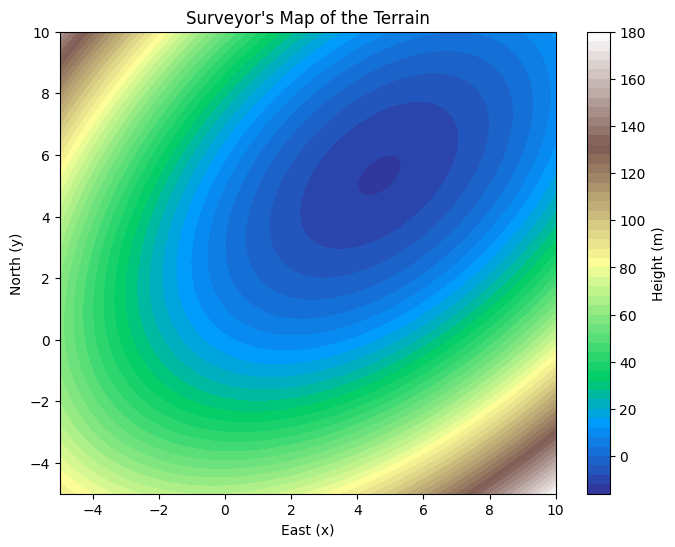

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Define our terrain height function
def f(coords):
    x, y = coords
    return (x - 2)**2 - x*y + (y - 3)**2

# Let's visualize the terrain first!
x_range = np.linspace(-5, 10, 100)
y_range = np.linspace(-5, 10, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = f([X, Y])

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, Z, levels=50, cmap='terrain')
plt.colorbar(label='Height (m)')
plt.title('Surveyor\'s Map of the Terrain')
plt.xlabel('East (x)')
plt.ylabel('North (y)')
plt.show()

## 1. The 'Bisection' Equivalent: Nelder-Mead

In one dimension, we use **Bisection** to narrow down an interval. In higher dimensions, we use the **Nelder-Mead (Simplex) method**. It doesn't use slopes (calculus); it just 'walks' a triangle (simplex) around the surface, flipping and shrinking it until it surrounds the lowest point.

In [ ]:
# We start at an arbitrary guess: (0, 0)
initial_guess = [0, 0]

# Nelder-Mead is a 'Direct Search' method (no derivatives needed!)
result_nm = minimize(f, initial_guess, method='Nelder-Mead')

print(f"Nelder-Mead found the minimum at x = {result_nm.x[0]:.2f}, y = {result_nm.x[1]:.2f}")
print(f"The height at this point is {result_nm.fun:.2f} meters.")

Nelder-Mead found the minimum at x = 4.67, y = 5.33
The height at this point is -12.33 meters.


## 2. Gradient Descent: Walking Downhill

Imagine you are standing on a hill in a thick fog. To get to the bottom, you feel the slope with your feet and take a step in the direction that goes down the steepest. This is **Gradient Descent**.

*   **Gradient**: A vector pointing 'uphill'.
*   **Negative Gradient**: The direction 'downhill'.

In [ ]:
def gradient(coords):
    x, y = coords
    # These formulas represent how steep the hill is in the x and y directions
    df_dx = 2*(x - 2) - y
    df_dy = -x + 2*(y - 3)
    return np.array([df_dx, df_dy])

# Simple Gradient Descent Loop
position = np.array([0.0, 0.0]) # Starting point
learning_rate = 0.1             # How big each step is

for i in range(50):
    grad = gradient(position)
    position = position - learning_rate * grad # Step away from the 'uphill' direction

print(f"Gradient Descent found the minimum at x = {position[0]:.2f}, y = {position[1]:.2f}")

Gradient Descent found the minimum at x = 4.64, y = 5.31


## 3. Newton's Method: Using Curvature

While Gradient Descent only looks at the slope, **Newton's Method** looks at the 'curvature' (how the slope is changing). It tries to jump directly to where it thinks the bottom is by approximating the terrain as a bowl (parabola). It is very fast but requires more information (the second derivative).

In [ ]:
# Newton's method uses the 'Hessian' (a matrix of second derivatives)
# For our function, the second derivatives are constants:
# d2f/dx2 = 2, d2f/dy2 = 2, d2f/dxdy = -1
hessian = np.array([[2, -1],
                    [-1, 2]])

position = np.array([0.0, 0.0])


# Mathematically, this step is calculated by multiplying the inverse of the
# Hessian matrix (which describes the curvature) by the Gradient vector
# (which describes the slope). However, inverting a matrix is computationally
# expensive and sometimes numerically unstable. Instead of calculating the
# inverse directly, we use np.linalg.solve(hessian, grad). This function
# efficiently solves the system of linear equations
# $H imes ext{step} = g$$H imes ext{step} = g$ for the unknown step.
# It effectively answers: 'By what vector must we multiply the curvature to
# get the current slope?' Subtracting this result from our current position
# moves us toward the minimum.

for i in range(5):
    grad = gradient(position)
    # position = position - (Hessian Inverse * Gradient)
    step = np.linalg.solve(hessian, grad)
    position = position - step

print(f"Newton's Method found the minimum at x = {position[0]:.2f}, y = {position[1]:.2f}")

Newton's Method found the minimum at x = 4.67, y = 5.33


## Try it Yourself!

1.  **Change the starting position**: What happens if you start at `[10, 10]`?
2.  **Adjust the learning rate**: In the Gradient Descent cell, change `0.1` to `0.8` or `0.001`. Does it still find the bottom?
3.  **New Terrain**: Can you change the `f(coords)` function to `x**2 + y**2` and see if the code still works?